Import

In [179]:
import pandas as pd
import numpy as np

In [180]:

FP_CO2_45 = '../../ODAC_data/45_CO2_fingerprints.csv'
FP_H2O_45 = '../../ODAC_data/45_H2O_fingerprints.csv'

FP_CO2_120 = '../../ODAC_data/120_CO2_fingerprints.csv'
FP_H2O_120 = '../../ODAC_data/120_H2O_fingerprints.csv'


def load_data(path=FP_CO2_45):
    return pd.read_csv(path)

In [181]:
loaded_data = load_data(FP_H2O_45)

loaded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4582 entries, 0 to 4581
Data columns (total 47 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   MOF                                   4582 non-null   object 
 1   atomic_num_mean                       4582 non-null   float64
 2   atomic_num_geometric_mean             4582 non-null   float64
 3   atomic_num_standard_deviation         4582 non-null   float64
 4   atomic_num_max                        4582 non-null   float64
 5   atomic_num_min                        4582 non-null   float64
 6   group_num_mean                        4582 non-null   float64
 7   group_num_geometric_mean              4582 non-null   float64
 8   group_num_standard_deviation          4582 non-null   float64
 9   group_num_max                         4582 non-null   float64
 10  group_num_min                         4582 non-null   float64
 11  period_num_mean  

In [182]:

def remove_outliers(df, multiplier=5):
    initial_shape = df.shape[0]

    df_numeric = df.select_dtypes(include=['number'])
    mask = pd.Series(True, index=df.index)

    for col in df_numeric.columns:
        Q1 = df[col].quantile(0.15)
        Q3 = df[col].quantile(0.85)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        mask &= df[col].between(lower_bound, upper_bound, inclusive='both')

    cleaned_df = df[mask]
    removed = initial_shape - cleaned_df.shape[0]

    print(f"Удалено выбросов: {removed}")
    print(f"Осталось строк: {cleaned_df.shape[0]}")

    return cleaned_df


In [183]:
data = loaded_data.drop(columns=['MOF'])

data = remove_outliers(data)

Удалено выбросов: 717
Осталось строк: 3865


In [184]:
X = data.drop(columns=['energy'])
y = data['energy']

In [185]:
print(f"Mean value: {np.mean(y):.4f}")
print(f"Average value: {np.average(y):.4f}")
print(f"Maximum value: {np.max(y):.4f}")
print(f"Minimum value: {np.min(y):.4f}")
print(f"Standard deviation: {np.std(y):.4f}")
print(f"Median value: {np.median(y):.4f}")
print(f"Number of samples: {len(y)}")

Mean value: -0.2895
Average value: -0.2895
Maximum value: 2.4022
Minimum value: -1.5654
Standard deviation: 0.3308
Median value: -0.3281
Number of samples: 3865


In [186]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [187]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', keep_empty_features=True)),
    ('scaler', StandardScaler()),
])

In [188]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def print_error(name, y_valid, pred):
    print('---------------------------------------------------------\n')
    print(f'Model: {name}')

    mae = mean_absolute_error(y_valid, pred)
    mse = mean_squared_error(y_valid, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_valid, pred)

    random_indices = np.random.choice(len(y_valid), 5, replace=False)
    print("\nRandom 5 predictions vs actual values:")
    for idx in random_indices:
        print(f"Predicted: {pred[idx]:.4f}, Actual: {y_valid.iloc[idx]:.4f}")

    print(f"\nMean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R² Score: {r2 * 100:.2f}%")


In [189]:
pipeline_reg = Pipeline([
    ('regressor', RandomForestRegressor())
])

param_grid = {
    'regressor': [
        RandomForestRegressor(n_estimators=100, random_state=42),
        ExtraTreesRegressor(n_estimators=100, random_state=42),
        BaggingRegressor(n_estimators=100, random_state=42)
    ]
}


In [190]:
X_train_transformed = pipeline.fit_transform(X_train)
X_valid_transformed = pipeline.transform(X_valid)

In [191]:
grid_search = GridSearchCV(pipeline_reg,
                           param_grid,
                           cv=5,
                           scoring='r2',
                           return_train_score=True
                           )
grid_search.fit(X_train_transformed, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor': [RandomForestR...ndom_state=42), ExtraTreesReg...ndom_state=42)]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [192]:
y_pred = grid_search.best_estimator_.predict(X_valid_transformed)
print_error('Grid', y_valid, y_pred)

---------------------------------------------------------

Model: Grid

Random 5 predictions vs actual values:
Predicted: -0.3136, Actual: -0.4147
Predicted: -0.2554, Actual: -0.4122
Predicted: -0.5758, Actual: -0.7491
Predicted: -0.1398, Actual: -0.1637
Predicted: -0.4321, Actual: -0.3604

Mean Absolute Error (MAE): 0.2109406209409843
Mean Squared Error (MSE): 0.10707816714371826
Root Mean Squared Error (RMSE): 0.3272280048280071
R² Score: 5.20%


In [193]:
from sklearn.model_selection import cross_val_score, KFold

model = RandomForestRegressor(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train_transformed, y_train, cv=kf)

print("score of every fold:", scores)
print("Average score:", np.mean(scores))

score of every fold: [ 0.00648298 -0.20056772 -0.00762551  0.0458323  -0.09722183]
Average score: -0.05061995634556895


In [194]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train_transformed, y_train,
                          scoring='neg_mean_squared_error', cv=kf)

print("MSE of every fold:", -scores)
print("Average MSE score:", -np.mean(scores))

MSE of every fold: [0.11976724 0.10247557 0.13990712 0.1330817  0.09587243]
Average MSE score: 0.11822081127327341


In [195]:
param_grid_rf = {
    'pca__n_components': [10, 15, 20, 30, 40, 45],
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2'],
    'model__bootstrap': [True, False]
}

param_grid_et = {
    'pca__n_components': [10, 15, 20, 30, 40, 45],
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2']
}

In [196]:
from sklearn.decomposition import PCA

pipe_rf = Pipeline([
    ('pca', PCA(random_state=42)),
    ('model', RandomForestRegressor(random_state=42))
])

pipe_et = Pipeline([
    ('pca', PCA(random_state=42)),
    ('model', ExtraTreesRegressor(random_state=42))
])



In [197]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# 🔍 GridSearchCV для ExtraTrees + PCA
grid_et = GridSearchCV(
    estimator=pipe_et,
    param_grid=param_grid_et,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [198]:

grid_rf.fit(X_train_transformed, y_train)
print("\nЛучшие параметры для RandomForest:")
print(grid_rf.best_params_)
print("Лучший результат (RMSE):", -grid_rf.best_score_)



Fitting 5 folds for each of 3888 candidates, totalling 19440 fits


C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
6480 fits failed out of a total of 19440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2599 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\GED\PycharmProjects\Aixelo_P


Лучшие параметры для RandomForest:
{'model__bootstrap': True, 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 500, 'pca__n_components': 10}
Лучший результат (RMSE): 0.328513110600421
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits

Лучшие параметры для ExtraTrees:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100, 'pca__n_components': 15}
Лучший результат (RMSE): 0.327528149646566


C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
3240 fits failed out of a total of 9720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2008 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\GED\PycharmProjects\Aixelo_Pr

In [ ]:
grid_et.fit(X_train_transformed, y_train)
print("\nЛучшие параметры для ExtraTrees:")
print(grid_et.best_params_)
print("Лучший результат (RMSE):", -grid_et.best_score_)

In [200]:
y_pred = grid_rf.best_estimator_.predict(X_valid_transformed)
print_error('RandomForest', y_valid, y_pred)

---------------------------------------------------------

Model: RandomForest

Random 5 predictions vs actual values:
Predicted: 0.1599, Actual: -0.3379
Predicted: -0.3467, Actual: -0.4723
Predicted: -0.2108, Actual: -0.4194
Predicted: -0.2342, Actual: -0.5406
Predicted: -0.3008, Actual: -0.6543

Mean Absolute Error (MAE): 0.20551441256129913
Mean Squared Error (MSE): 0.10824527421796895
Root Mean Squared Error (RMSE): 0.32900649570786433
R² Score: 4.16%


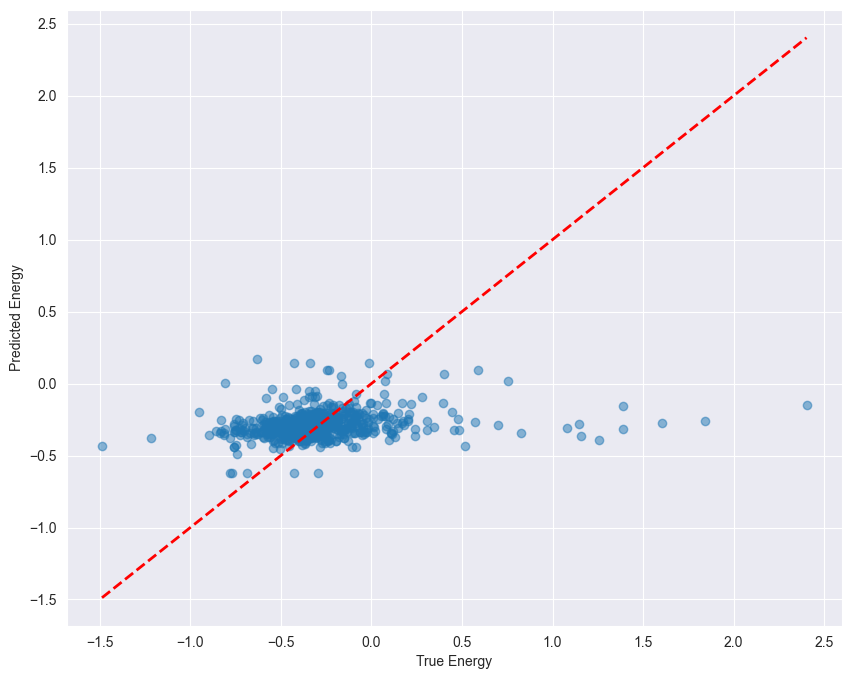

In [203]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(y_valid, y_pred, alpha=0.5)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], 'r--', linewidth=2)  # линия y=x
plt.xlabel('True Energy')
plt.ylabel('Predicted Energy')
plt.grid(True)
plt.show()

In [201]:
y_pred = grid_et.best_estimator_.predict(X_valid_transformed)
print_error('ExtraTrees', y_valid, y_pred)

---------------------------------------------------------

Model: ExtraTrees

Random 5 predictions vs actual values:
Predicted: -0.2395, Actual: -0.2159
Predicted: -0.3505, Actual: -0.3351
Predicted: -0.3110, Actual: -0.3006
Predicted: -0.2752, Actual: -0.5158
Predicted: -0.2278, Actual: -0.4194

Mean Absolute Error (MAE): 0.20440451958277364
Mean Squared Error (MSE): 0.1073566225964533
Root Mean Squared Error (RMSE): 0.32765320477061305
R² Score: 4.95%


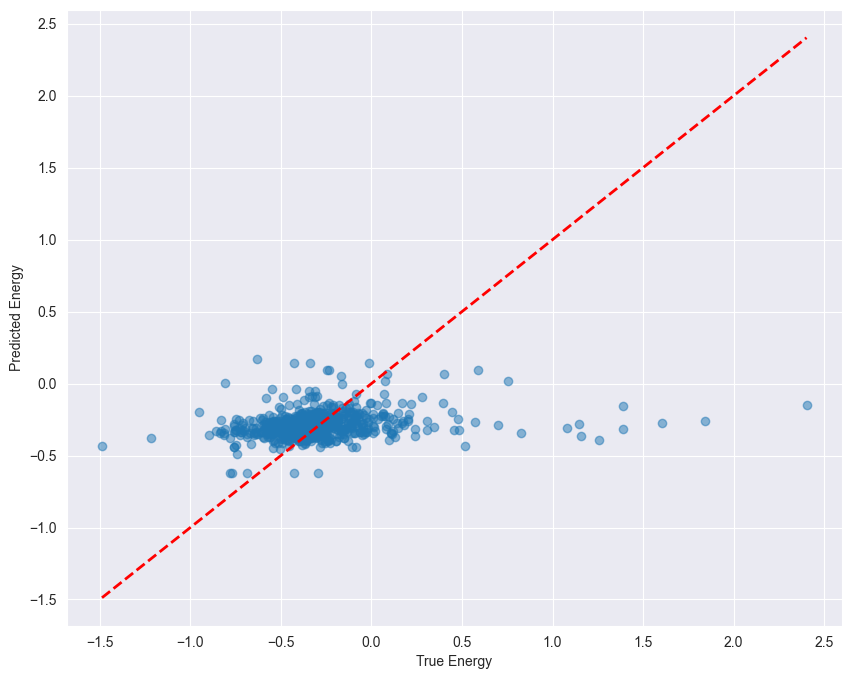

In [204]:
plt.figure(figsize=(10, 8))
plt.scatter(y_valid, y_pred, alpha=0.5)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], 'r--', linewidth=2)
plt.xlabel('True Energy')
plt.ylabel('Predicted Energy')
plt.grid(True)
plt.show()